In [1]:
print ("hello this ready")

hello this ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("✓ All libraries loaded!")

✓ All libraries loaded!


In [3]:
!pip install plotly

df = pd.read_csv('../data/raw/winemag-data-130k-v2.csv')
df

In [18]:
# How many rows vs columns
df.shape

(129971, 14)

In [5]:
df.sample(10)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
17857,17857,US,"Alcoholic, volatile nose, with some pickley ed...",NaN,85,18.0,California,Fiddletown,Sierra Foothills,Paul Gregutt,@paulgwine,Sobon Estate 1998 Zinfandel (Fiddletown),Zinfandel,Sobon Estate
7176,7176,South Africa,"This Cabernet-basred blend, with 13% Merlot, 4...",Tiara,90,36.0,Stellenbosch,NaN,NaN,Lauren Buzzeo,@laurbuzz,Simonsig 2010 Tiara Red (Stellenbosch),Bordeaux-style Red Blend,Simonsig
92111,92111,Germany,Dazzling acidity and crisp red cherry and plum...,Bürgstadter Trocken,91,50.0,Franken,NaN,NaN,Anna Lee C. Iijima,NaN,Rudolf Fürst 2012 Bürgstadter Trocken Spätburg...,Spätburgunder,Rudolf Fürst
18936,18936,France,"Full, ripe and juicy, this has a flavor of fre...",NaN,91,20.0,Bordeaux,Médoc,NaN,Roger Voss,@vossroger,Château des Lattes 2010 Médoc,Bordeaux-style Red Blend,Château des Lattes
56305,56305,Portugal,The wine is all about fresh fruit. Blackberry ...,Cascas Winemaker Selection,86,10.0,Alentejano,NaN,NaN,Roger Voss,@vossroger,Casca Wines 2015 Cascas Winemaker Selection Re...,Portuguese Red,Casca Wines
58983,58983,Italy,"Aromas of toasted oak, vanilla and a confectio...",Mongris Riserva,88,30.0,Northeastern Italy,Collio,NaN,Kerin O’Keefe,@kerinokeefe,Marco Felluga 2012 Mongris Riserva Pinot Grigi...,Pinot Grigio,Marco Felluga
58408,58408,Italy,"Aromas of wild flower, black fruit and toast l...",San Gaetano,85,12.0,Southern Italy,Primitivo di Manduria,NaN,Kerin O’Keefe,@kerinokeefe,Cantine Due Palme 2012 San Gaetano (Primitivo...,Primitivo,Cantine Due Palme
48061,48061,Italy,"This is fresh, with lush layers of peach, melo...",NaN,87,17.0,Northeastern Italy,Colli Orientali del Friuli,NaN,NaN,NaN,Ermacora 2010 Pinot Grigio (Colli Orientali de...,Pinot Grigio,Ermacora
57468,57468,France,"The wine is light, fresh and fruity. Red berry...",NaN,86,NaN,Bordeaux,Côtes de Bourg,NaN,Roger Voss,@vossroger,Château Blanchereau 2011 Côtes de Bourg,Bordeaux-style Red Blend,Château Blanchereau
5044,5044,US,Winemaker Anna Monticelli spent a harvest at C...,Firehouse Vineyard,91,85.0,California,Rutherford,Napa,Virginie Boone,@vboone,Piña 2011 Firehouse Vineyard Cabernet Sauvigno...,Cabernet Sauvignon,Piña


Observations: 
1. Remove unnamed columns, taster name, taste twitter handle, region2
2. Province are there for most of them, but region information is missing for some
3. Need to clean title, description
4. Potentially remove designation since we already have winery given
5. Clean title, description, country, province, region1, and veriety

In [35]:
# Drop some columns
# inplace = True means the dataFrame is modified in place
df.drop(["Unnamed: 0", "taster_name", "taster_twitter_handle"], axis=1, inplace=True)
df

,country,description,designation,points,price,province,region_1,region_2,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...,...,...,...,...,...
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


In [38]:
# After we remove unnamed: 0 column, we have removed the unique index. Now, we should calculate 
# all the duplicate values in our data set. 
dup_rows = df.duplicated(keep="first")
print ('Duplicate Rows: ', dup_rows.sum())
print(df[dup_rows].sort_values(by='country'))

Duplicate Rows:  9983
          country                                        description  \
102757  Argentina  Raw black-cherry aromas are direct and simple ...   
26293   Argentina  Four years running this wine has scored 87 and...   
64343   Argentina  Ripe, deep aromas of cassis and marzipan evolv...   
92611   Argentina  Solid on the bouquet, this has notes of dark f...   
43664   Argentina  Sweet oak and vanilla aromas are front and cen...   
...           ...                                                ...   
18460     Uruguay  Dried blackberry aromas include welcome notes ...   
79827         NaN  An interesting blend of indigenous Bulgarian a...   
106170        NaN  This is a reasonably rich, concentrated exampl...   
116307        NaN  A lively whiff of white blossom, Muscat grapes...   
118118        NaN  Amber to the eye, this wine features an entici...   

                                designation  points  price          province  \
102757                  Winemaker

In [41]:
# keep = first, drops everything except the first unique value, inplace = True, ignore_index gives us a continous dataset
df.drop_duplicates(keep='first', inplace = True, ignore_index=True)
# After dropping, this is the new shape
df.shape

(119988, 11)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119988 entries, 0 to 119987
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   country      119929 non-null  object 
 1   description  119988 non-null  object 
 2   designation  85443 non-null   object 
 3   points       119988 non-null  int64  
 4   price        111593 non-null  float64
 5   province     119929 non-null  object 
 6   region_1     100428 non-null  object 
 7   region_2     46769 non-null   object 
 8   title        119988 non-null  object 
 9   variety      119987 non-null  object 
 10  winery       119988 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 10.1+ MB


Observation
1. The types of all the features is correct. So, price is float64 and points is int64.

In [44]:
df.isnull().sum().sort_values(ascending=True)

description        0
points             0
title              0
winery             0
variety            1
country           59
province          59
price           8395
region_1       19560
designation    34545
region_2       73219
dtype: int64

Observation: 
1. Both country and province are missing the same number of missing values. It could be country and province has same missing rows. 

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
points,119988.0,88.442236,3.092915,80.0,86.0,88.0,91.0,100.0
price,111593.0,35.620747,42.103728,4.0,17.0,25.0,42.0,3300.0


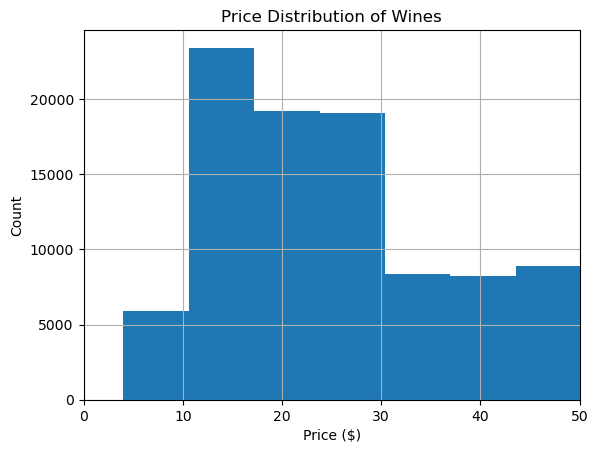

In [46]:
# Price distribution
df['price'].hist(bins=500)
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.title('Price Distribution of Wines')
# Update the scale of the graph
plt.xlim(0,50)
plt.show()

Observation
1. Data is left-skewed, so we can apply a log transform to it.
2. More than 25000 wines are priced between $10 and $20
3. We had to change the range of the x-axis from 0 - 50 to properly visualize the data

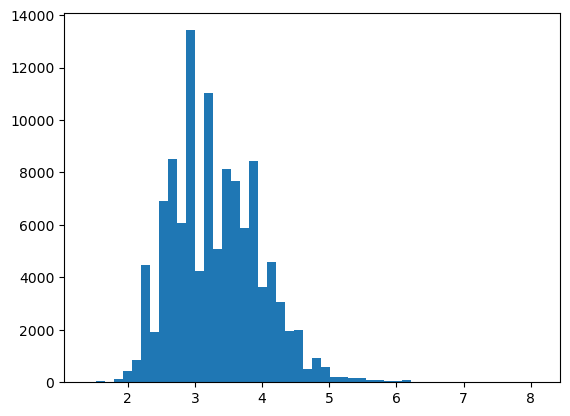

In [47]:
# Logarithmic plot to convert the left skewed data into a vieqw
plt.hist(np.log(df['price']), bins=50)
plt.show()

Observation
1. This has removed skewness
2. We will add this logarithmic values into our dataframe

In [12]:
# Check the outliers in the data
(df['price']>100).sum()

np.int64(3366)

In [54]:
# Calculate unique variety of wine in this dataset
df['variety'].value_counts().shape

(707,)

<Axes: ylabel='variety'>

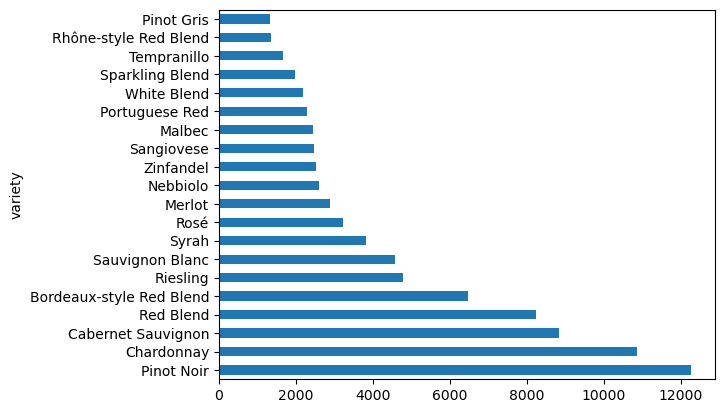

In [50]:
# Top 20 wine varieties
# Calculate unique entries using value_counts(), get the top 20 and plot it as a horizontal bar graph 
df['variety'].value_counts().head(20).plot(kind='barh')

Observation:
1. We can observe the Pinot Noir is the most reviewed wine in this dataset, followed by Chardonnay

<Axes: xlabel='country'>

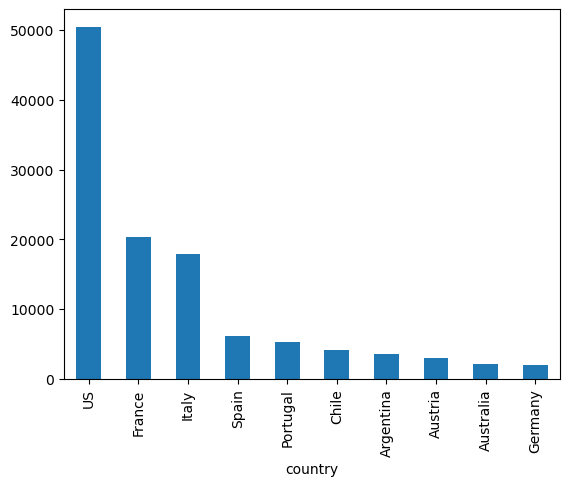

In [56]:
# Most reviewed from a country
df['country'].value_counts().head(10).plot(kind='bar')

In [ ]:
Observation:
1. US has the most reviewed wines currently, out of 38 countries

In [67]:
# Unique countries
df['country'].value_counts().sort_index().shape

(43,)

Text(0, 0.5, 'rating')

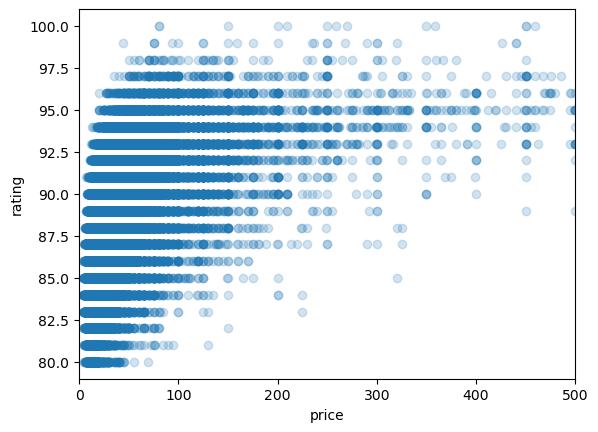

In [78]:
# A scatter plot is simply a plot between two features. It's used to find a relationship between the two.
# Here, we create a scatter plot between price and points. A scatter plot can only be used with "numerical" values
# because we need two numerical points to plot them on a graph.
plt.scatter(df['price'], df['points'], alpha = 0.2)
plt.xlim(0, 500)
plt.xlabel("price")
plt.ylabel("rating")

In [87]:
# Are price and points related to each other?
# The result is between 0-1. Closer to 1 means they are related to each other
# Closer to 0 means they are not related to each other.
# This tells us there is a relationship, but we don't know what it is.
df[['price', 'points']].corr()

,price,points
price,1.000000,0.416534
points,0.416534,1.000000


Observation:
1. Weak correllation between price and points feature